# 02 — Open loop versus closed loop

**Feedforward is correct exactly as long as the world matches your model.**

Before spending an hour on feedback it is worth asking why anyone would bother. We have a model
of this car that predicted its terminal speed correctly in notebook 01. So compute the throttle
that holds 90 km/h, apply it, and drive. No sensor, no loop, nothing to tune.

That is **feedforward**, and this notebook starts by doing exactly it. It works. The car sits on
90.00 km/h, and it is not a trick — feedforward is cheap, fast, and cannot oscillate, because
there is no loop to go unstable.

Then we change the world three times, in ways any driver would recognize: a shallow hill, some
luggage in the boot, a headwind. The controller goes on being right. The car does not.

The second half closes the loop with a proportional controller that knows none of those three
things, and gets all three back. The closing point matters as much as the failures: feedback
does not merely correct errors, it changes the system's dynamics — which is why a badly tuned
loop can be worse than no loop at all, and why the rest of the lecture exists.

Speeds are in km/h everywhere, because the model emits km/h through `Vehicle.ToKmPerHour`. The
control loop runs in km/h too, so the gain `k` is a number in N.m per km/h.


## Setup

`support.jl` carries the boilerplate shared by all ten notebooks: the environment bootstrap,
the parameter set, the sweep machinery, and the plotting and readout conventions. It carries
no physics.


In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. Two architectures

There are only two ways to build a controller, and the difference between them is one wire.

```
  open loop                                 d
                                            |
                                            v
       r --->+------------+   u   +---------------+
             | controller |------>|      car      |----> y
             +------------+       +---------------+


  closed loop                                    d
                                                 |
                e                                v
       r -->(-)-->+------------+   u   +---------------+
             ^    | controller |------>|      car      |--+--> y
             |    +------------+       +---------------+  |
             +--------------------------------------------+
```

`r` is the reference — the speed the driver asked for. `u` is the command the controller
produces, a torque. `y` is what the car actually does. `d` is the disturbance: everything acting
on the car that nobody put there on purpose.

**Open loop, or feedforward.** The reference is fed forward and never comes back. To produce `u`
from `r`, the controller has to run the car backwards: *given the speed I want, what torque
achieves it?* That is model inversion, and it means a feedforward controller contains a model of
the plant — mass, drag area, rolling coefficient, wheel radius, gear ratio, all of it. Any error
in that model becomes an error in the output, permanently.

**Closed loop, or feedback.** The output is measured and subtracted from the reference. The
difference is the **error**, `e = r - y`, and the error is the only thing the controller acts on.
It needs no model of the car at all. What it needs is a sensor.

Look at what the extra wire buys and what the missing one costs. In the open-loop picture there
is no error signal anywhere. Not a small one, not a slow one — the quantity does not exist. Trace
any path in that diagram and nothing ever compares what was asked for with what happened. That is
the whole of this notebook, and everything below is a consequence of it.

Feedback is not obviously the better idea, and it is worth being honest about that before selling
it. It is a concession we are forced into because we cannot know the plant and the world well
enough to invert them. Given perfect knowledge we would not want the extra wire — it brings
problems of its own, and section 6 names them.


## 2. Invert the model

Notebook 01 wrote the force balance for this car:

$$
m\frac{dv}{dt} \;=\; \underbrace{T\frac{i}{r}}_{\text{tractive}}
\;-\; \underbrace{\tfrac{1}{2}\rho C_{d}A\,v^{2}}_{\text{drag}}
\;-\; \underbrace{f_{r}mg\cos\alpha}_{\text{rolling}}
\;-\; \underbrace{mg\sin\alpha}_{\text{grade}}
$$

Cruising means $dv/dt = 0$. On a flat road $\alpha = 0$, so the last term vanishes and the cosine
is one. Set $v$ to the speed we want and solve for the torque instead of for the speed:

$$
T_{ff} \;=\; \left(\tfrac{1}{2}\rho C_{d}A\,v^{2} + f_{r}mg\right)\frac{r}{i}
$$

That is the inversion, and it is the entire controller. One number, computed once, applied
forever. Everything the controller knows about this car is in that line.


In [3]:
V_TARGET = 90.0                 # km/h, the speed the driver asked for
v = V_TARGET / 3.6              # m/s, because the force balance is in SI

F_drag = 0.5 * CAR.rho * CAR.CdA * v^2      # N
F_roll = CAR.f_r * CAR.m * CAR.g            # N, flat road: cos(alpha) = 1
F_total = F_drag + F_roll                   # N of tractive force needed at the road

tau_ff = F_total * CAR.r / CAR.i            # N.m at the engine, driveline run backwards

println("target speed      ", V_TARGET, " km/h  =  ", round(v, digits = 3), " m/s")
println("drag              ", round(F_drag, digits = 2), " N")
println("rolling           ", round(F_roll, digits = 2), " N")
println("tractive needed   ", round(F_total, digits = 2), " N")
println("feedforward torque", "  ", round(tau_ff, digits = 3), " N.m")
println("engine limit      ", CAR.T_max, " N.m — this asks for ",
        round(100 * tau_ff / CAR.T_max, digits = 1), "% of it")

target speed      90.0 km/h  =  25.0 m/s
drag              236.25 N
rolling           164.75 N
tractive needed   401.0 N
feedforward torque  31.078 N.m
engine limit      150.0 N.m — this asks for 20.7% of it


### The model this runs

[`Lecture1.FeedforwardCruise`](../../dyad/Lecture1/FeedforwardCruise.dyad) is the car of
notebook 01 with a constant torque wired to its command input and a constant grade wired to its
road input. There is no controller component in it, because a feedforward controller with a
constant reference *is* a number.

The harness exposes the four things this notebook varies as its own parameters — `tau_ff`,
`grade`, `m` and `CdA` — so a cell below changes the world by naming the quantity that changed,
not by reaching down a path into the plant's internals. It starts the car in equilibrium at
`v0`, with the engine's lag state preloaded to `tau_ff`; without that the run would spend
several hundred seconds settling before anything interesting happened, because the car's own
time constant is about 60 s.


In [4]:
show_dyad("FeedforwardCruise")

FeedforwardCruise — dyad/Lecture1/FeedforwardCruise.dyad line 1 
 """
Open-loop feedforward cruise: a fixed torque computed from the nominal force balance.

The command is a constant `tau_ff` — the torque that holds the target speed on the nominal car
on flat road, run backwards through the driveline from the steady-state force balance. There is
no measurement and no correction: the plant is driven open loop, so the settled speed is exactly
right only when the world matches the model the torque was computed for. `grade`, `m` and `CdA`
are exposed so notebook 02 can perturb that world and show the open-loop error each perturbation
produces.

The lag state is preloaded with `tau_ff` and the speed with `v0`, so the nominal run begins
already settled instead of spending the vehicle's ~60 s time constant getting there.
"""
component FeedforwardCruise
 plant = VehicleSystemsComponents.Vehicle.CarPlant(m = m, CdA = CdA) {^plant}
 "Fixed feedforward torque command"
 cmd = BlockComponents.Sources.Constant(k = tau_ff) {^cmd}
 "Constant road gradient"
 road = BlockComponents.Sources.Constant(k = grade) {^road}
 "Feedforward torque holding the target speed on the nominal car"
 parameter tau_ff::Torque = 31.078
 "Constant road gradient, tan(alpha)"
 parameter grade::Real = 0.0
 "Vehicle mass"
 parameter m::Dyad.Mass = 1400.0
 "Aerodynamic drag area (Cd * A)"
 parameter CdA::Area = 0.63
 "Initial speed (25 m/s = 90 km/h)"
 parameter v0::Velocity = 25.0
relations
 connect(cmd.y, plant.tau_cmd) {^id4}
 connect(road.y, plant.grade) {^id5}
 initial plant.body.mass.s = 0.0
 initial plant.body.mass.v = v0
 initial plant.engine.lag.x = tau_ff
metadata {
 "Dyad": {
 "tests": {
 "nominal": {
 "stop": 400,
 "atol": {"plant.v_kmh": 0.05, "plant.engine.limiter.y": 0.001},
 "expect": {
 "initial": {"plant.v_kmh": 90, "plant.engine.limiter.y": 31.078},
 "final": {"plant.v_kmh": 90, "plant.engine.limiter.y": 31.078},
 "signals": ["plant.v_kmh", "plant.engine.limiter.y", "cmd.y"]
 }
 }
 }
 },
 "_links": {
 "plant": {
 "Dyad": {"placement": {"diagram": {"x1": 158, "x2": 258, "y1": 20, "y2": 120}}}
 },
 "cmd": {"Dyad": {"placement": {"diagram": {"x1": 20, "x2": 120, "y1": 20, "y2": 120}}}},
 "road": {
 "Dyad": {"placement": {"diagram": {"x1": 10, "x2": 110, "y1": 250, "y2": 350}}}
 },
 "id4": {"Dyad": {"edges": [{"S": 1, "M": [], "E": 2}], "path": {}}},
 "id5": {"Dyad": {"edges": [{"S": 1, "M": [{"x": 210, "y": 300}], "E": 2}], "path": {}}}
 }
}
end

commanded torque  31.078 N.m
delivered torque  31.078 N.m
settled speed     90.0 km/h
error             0.0 km/h


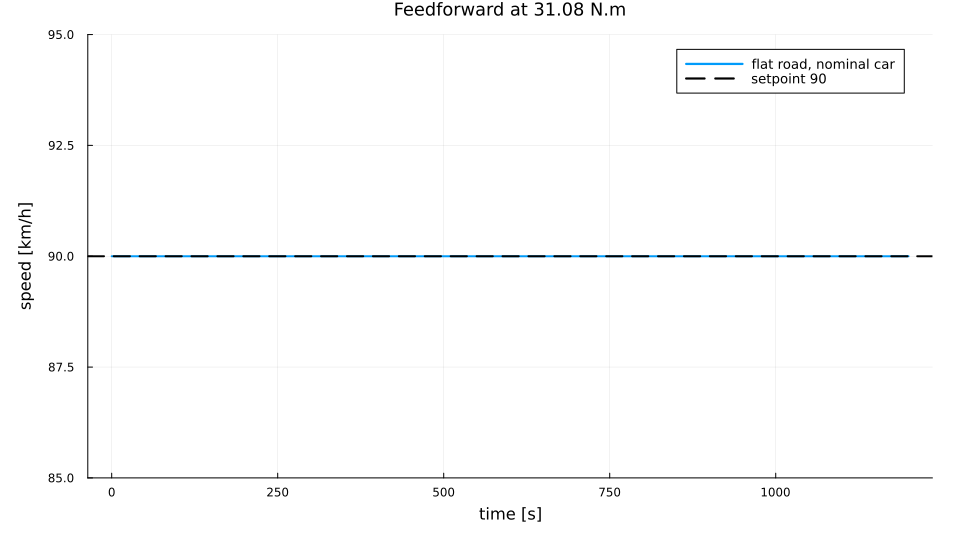

In [5]:
Scenarios = VehicleSystemsComponents.Lecture1

# 1200 s of simulated time. The nominal run settles instantly because it starts settled, but
# the 1% climb of section 3 falls 32 km/h against nothing but drag and needs eleven minutes to
# finish arriving. All four runs share one window so the curves can be compared.
STOP = 1200.0

nominal = Scenarios.FeedforwardCruiseTransient(tau_ff = tau_ff, stop = STOP)

v_settled = signal(nominal, "plant.v_kmh")[2][end]
println("commanded torque  ", round(signal(nominal, "cmd.y")[2][end], digits = 3), " N.m")
println("delivered torque  ", round(signal(nominal, "plant.engine.limiter.y")[2][end], digits = 3), " N.m")
println("settled speed     ", round(v_settled, digits = 3), " km/h")
println("error             ", round(abs(V_TARGET - v_settled), digits = 4), " km/h")

plot_speed(nominal; setpoint = V_TARGET, label = "flat road, nominal car",
           title = "Feedforward at $(round(tau_ff, digits = 2)) N.m", ylims = (85, 95))

**It works.** No sensor, no error signal, no controller worth the name, and the car holds
90 km/h to the precision the solver prints. On a flat road, in the car we modeled, feedforward
is exactly right — not approximately right, not right enough, right.

This is a legitimate control strategy and not a straw man. It is cheap: one multiplication, done
once, on paper. It is fast: the command is correct from the first instant, with no loop that has
to settle. And it cannot destabilize anything, because there is no loop to go unstable. A great
deal of real control is feedforward, and the good designs that also use feedback usually keep a
feedforward path alongside it and let the loop correct only the residue.

What has to be true for it to keep working? Everything in that one line. Mass, drag area,
rolling coefficient, wheel radius, gear ratio, air density, and a road that is flat.


## 3. Break it three ways

Three changes, none of them exotic, none of them a fault:

| | change | what it is |
|---|---|---|
| a | `grade = 0.01` | a 1% rise — a motorway gradient, about 0.6 degrees |
| b | `m = 1600` | 200 kg in the car: two passengers and their luggage |
| c | `CdA = 0.756` | a headwind, as a 20% increase in effective drag area |

The torque command does not change. It is still 31.078 N.m, still correct for the car it was
computed for, and still delivered in full — none of these cases goes anywhere near the engine's
150 N.m ceiling.

**A note on the gradient, because 1% looks timid.** It is not chosen for gentleness, it is
chosen because anything much larger stops teaching the lesson. 31.078 N.m is 401 N of tractive
force at the road. A 4% grade costs about 549 N of it on its own, which is more than the whole
budget — so on a 4% climb the car does not settle at a lower speed, it decelerates to a stop and
rolls backwards. True, dramatic, and a different lesson. What we want to show is the controller
being *right* while the world moves out from under it, and for that the car has to keep driving.

Each settling speed can be read off the force balance before anything is simulated. Set
$dv/dt = 0$ with the tractive force pinned at whatever 31.078 N.m buys, and solve for $v$:

$$
v_\infty \;=\; \sqrt{\frac{T_{ff}\,i/r \;-\; f_{r}mg\cos\alpha \;-\; mg\sin\alpha}
{\tfrac{1}{2}\rho C_{d}A}}
$$


In [6]:
F_tractive = tau_ff * CAR.i / CAR.r         # N, fixed: the command never changes

# The world, as four sets of the three things the harness exposes. Nothing else differs
# between these runs — same car model, same command, same initial condition.
WORLDS = [
    ("flat road, nominal car", (grade = 0.0,  m = CAR.m,       CdA = CAR.CdA)),
    ("1% grade",               (grade = 0.01, m = CAR.m,       CdA = CAR.CdA)),
    ("200 kg payload",         (grade = 0.0,  m = CAR.m + 200, CdA = CAR.CdA)),
    ("20% more drag area",     (grade = 0.0,  m = CAR.m,       CdA = 1.2 * CAR.CdA)),
]

function predicted_speed(w)
    alpha = atan(w.grade)
    resisted = F_tractive - CAR.f_r * w.m * CAR.g * cos(alpha) - w.m * CAR.g * sin(alpha)
    return 3.6 * sqrt(resisted / (0.5 * CAR.rho * w.CdA))     # km/h
end

println("  world                     predicted settling speed")
for (name, w) in WORLDS
    println("  ", rpad(name, 24), "  ", lpad(round(predicted_speed(w), digits = 2), 6), " km/h")
end

  world                     predicted settling speed
  flat road, nominal car      90.0 km/h
  1% grade                   58.25 km/h
  200 kg payload              85.4 km/h
  20% more drag area         82.16 km/h


  world                     simulated   predicted    command
  flat road, nominal car      90.0 km/h    90.0 km/h     31.078 N.m
  1% grade                   58.25 km/h   58.25 km/h     31.078 N.m
  200 kg payload              85.4 km/h    85.4 km/h     31.078 N.m
  20% more drag area         82.16 km/h   82.16 km/h     31.078 N.m


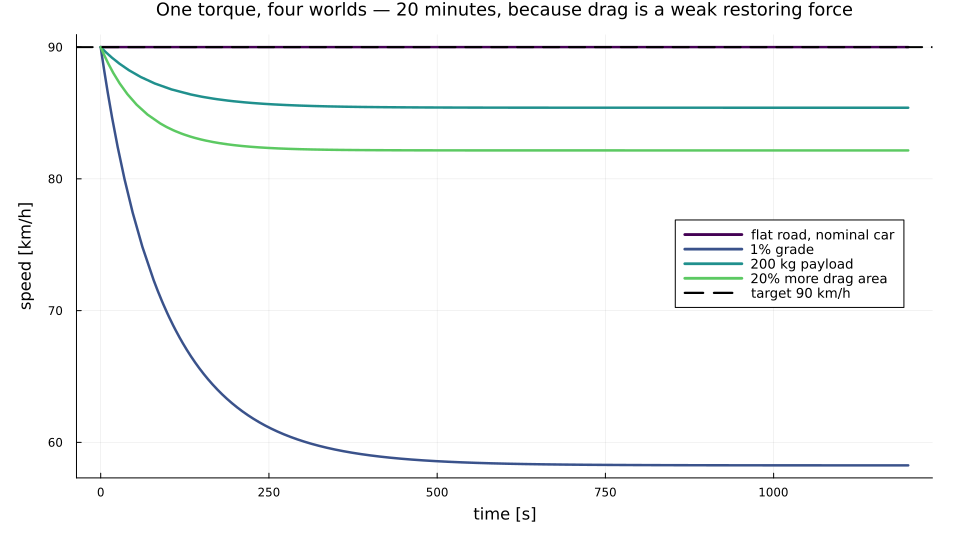

In [7]:
open_loop = [name => Scenarios.FeedforwardCruiseTransient(
                 tau_ff = tau_ff, grade = w.grade, m = w.m, CdA = w.CdA, stop = STOP)
             for (name, w) in WORLDS]

println("  world                     simulated   predicted    command")
for ((name, w), (_, sol)) in zip(WORLDS, open_loop)
    settled = signal(sol, "plant.v_kmh")[2][end]
    println("  ", rpad(name, 24), "  ", lpad(round(settled, digits = 2), 6), " km/h",
            "  ", lpad(round(predicted_speed(w), digits = 2), 6), " km/h",
            "     ", round(signal(sol, "cmd.y")[2][end], digits = 3), " N.m")
end

plt = plot(; xlabel = "time [s]", ylabel = "speed [km/h]",
           title = "One torque, four worlds — 20 minutes, because drag is a weak restoring force",
           legend = :right)
for (n, (name, sol)) in enumerate(open_loop)
    t, y = signal(sol, "plant.v_kmh")
    plot!(plt, t, y; lw = 2.5, label = name, color = palette(:viridis, 5)[n])
end
hline!(plt, [V_TARGET]; ls = :dash, lw = 2, color = :black, label = "target 90 km/h")
save_figure(plt, "02-open-loop-broken")
plt

Three curves leave the target and never come back, and the simulated speeds land on the
predicted ones, which is the check worth making: the force balance and the model agree, so the
arithmetic above is describing this car and not a different one.

The time axis is worth a look on its own, and it is why the window is twenty minutes. These are
not fast failures. The payload case is within half a km/h of its new speed after about three
minutes; the climb needs eleven to finish falling. The only thing pulling this car back towards
equilibrium is drag, drag is a weak restoring force, and the further the speed falls the weaker
it gets. A driver watching the speedometer would see the number sag so slowly that it never
looks like an event.

Read the three off the plot in order of how noticeable they are. The hill is obvious — the car
loses more than 30 km/h and any driver would reach for the pedal. The headwind costs
7.8 km/h. The luggage costs 4.6 km/h, and that one is the interesting case: nobody notices it at
all. The car is simply, permanently, quietly slower than it was asked to be.


## 4. What went wrong

**Nothing in the controller.**

That is not a rhetorical flourish, it is the finding. The controller computed 31.078 N.m; it
commanded 31.078 N.m; the engine delivered 31.078 N.m — the command column of the table in
section 3 reads the same in every run. Every component did precisely what it was designed to do, and at no point did
anything fail, drift, or go out of calibration.

What went wrong is that the controller is answering a question about a car that no longer
exists. 31.078 N.m is the right torque for a 1400 kg car with 0.63 m² of drag area on a flat
road. Add a hill and that car is gone. The number is still a correct answer; it is an answer to
the wrong question, and nothing in the architecture can tell the difference.

And this is the part to hold on to: **the car is not failing to correct itself — it has no
concept of correction.** Go back to the open-loop diagram in section 1 and look for the quantity
"how far off are we". It is not there. It is not small, or noisy, or slow to arrive; it does not
exist. There is no sensor, so nothing is measured; nothing is measured, so nothing is compared;
nothing is compared, so there is no error signal for any part of the system to respond to.

That is the argument for feedback, and it is worth stating as a design principle rather than as
a fix for these three cases. A feedforward controller's accuracy is exactly the accuracy of its
model of the world. You can improve it — weigh the car, measure the road, put an anemometer on
the roof — and every one of those improvements is a new model that will also be wrong in some
new way. Or you can measure the one thing you actually care about, which is the speed, and act
on the difference.


## 5. Close the loop

Same car, same three disturbances, same initial condition — 90 km/h with the engine already
delivering 31.078 N.m. The difference is the wire.

[`Lecture1.CruiseLoop`](../../dyad/Lecture1/CruiseLoop.dyad) is the plant with a controller
closed around it: the plant's speed in km/h goes to the controller's measurement input, and the
controller's output goes to the plant's torque command. The controller is
`BlockComponents.Continuous.LimPID`, and the scenario harness ships with `with_I` and
`with_D` both off, which leaves

$$
u(t) \;=\; k \cdot e(t), \qquad e(t) \;=\; v_{set} - v(t)
$$

and nothing else. Both booleans are *structural*, so the integral and derivative paths are not
set to zero — they are not built. Notebook 03 takes this same controller apart properly; here it
is only the simplest device that uses an error signal at all.

**Two things about this setup, stated before they are used.**

*The gain is `k = 25` N.m per km/h,* comfortably under a quarter of the gain at which this loop
starts to oscillate and never stop (`Ku = 114.58`, measured in notebook 08). It is a perfectly ordinary
working gain and nothing here depends on its exact value.

*The engine's torque limit is lifted.* `T_max` and `y_max` both go far above anything the run
will ask for, so assume for now an engine that delivers whatever it is told. Notebook 06 removes
that assumption and makes a lecture out of what happens next — the limit is introduced there
deliberately, and it is not allowed to complicate anything before it.

Notice what the loop is *not* given. It is not told the grade. It is not told the mass. It is
not told that anything has changed at all.


In [8]:
show_dyad("CruiseLoop")

CruiseLoop — dyad/Lecture1/CruiseLoop.dyad line 1 
 """
Cruise-control loop around the longitudinal car plant.

The setpoint and feedback signal are both in km/h, so `k` is interpreted as N.m per km/h.
Integral and derivative action are removed structurally when disabled; the same assembly therefore
serves the P, PI, and PID lecture notebooks.
"""
component CruiseLoop
 "Vehicle-speed setpoint in km/h"
 setpoint = RealInput()
 "Road gradient, tan(alpha)"
 grade = RealInput()
 "Powertrain transport delay"
 structural parameter theta_e::Time = 0.3
 "Whether to include integral action"
 structural parameter with_I::Boolean = true
 "Whether to include derivative action"
 structural parameter with_D::Boolean = true
 "Controller gain in N.m per km/h"
 parameter k::Real = 56.0
 parameter Ti::Time = 10.0
 parameter Td::Time = 0.1
 parameter Nd::Real = 10.0
 parameter Ni::Real = 0.9
 "Physical engine torque ceiling"
 parameter T_max::Torque = 150.0
 "Controller output ceiling; defaults to the physical ceiling"
 parameter y_max::Real = T_max
 parameter y_min::Real = 0.0
 parameter wp::Real = 1.0
 parameter wd::Real = 1.0
 "Vehicle mass"
 parameter m::Dyad.Mass = 1400.0
 "Aerodynamic drag area (Cd * A)"
 parameter CdA::Area = 0.63
 "Initial measured speed in km/h, the settled cruise the loop starts from"
 parameter m0::Real = 90.0
 "Initial integrator state"
 parameter xi0::Real = 0.0
 # The derivative filter tracks its input wd*u_s - u_m. Starting it at zero while the
 # measurement is already m0 makes the filter see a step of -u_m at t=0 and command a spike
 # of -k*Nd*m0 (e.g. -50400 N.m at k=56, Nd=10, m0=90 with wd=0). Seeding it at the settled
 # value (wd-1)*m0 — the input the filter would hold at a steady cruise where u_s = u_m = m0 —
 # removes that spike while preserving any genuine derivative kick on a later setpoint change.
 "Initial derivative-filter state, seeded from the initial measurement"
 parameter xd0::Real = (wd - 1) * m0
 plant = VehicleSystemsComponents.Vehicle.CarPlant(theta_e = theta_e, T_max = T_max, m = m, CdA = CdA)
 controller = BlockComponents.Continuous.LimPID(
 with_I = with_I,
 with_D = with_D,
 k = k,
 Ti = Ti,
 Td = Td,
 Nd = Nd,
 Ni = Ni,
 y_max = y_max,
 y_min = y_min,
 wp = wp,
 wd = wd,
 xi0 = xi0,
 xd0 = xd0)
 "No separate feedforward path in this feedback loop"
 zero_ff = BlockComponents.Sources.Constant(k = 0.0)
relations
 connect(setpoint, controller.u_s)
 connect(plant.v_kmh, controller.u_m)
 connect(zero_ff.y, controller.u_ff)
 connect(controller.y, plant.tau_cmd)
 connect(grade, plant.grade)
end

  world                     open loop    closed loop    error    holding torque
  flat road, nominal car      90.0 km/h   88.78 km/h   1.22 km/h      30.58 N.m
  1% grade                   58.25 km/h   88.36 km/h   1.64 km/h      41.05 N.m
  200 kg payload              85.4 km/h    88.7 km/h    1.3 km/h      32.38 N.m
  20% more drag area         82.16 km/h   88.64 km/h   1.36 km/h      34.08 N.m


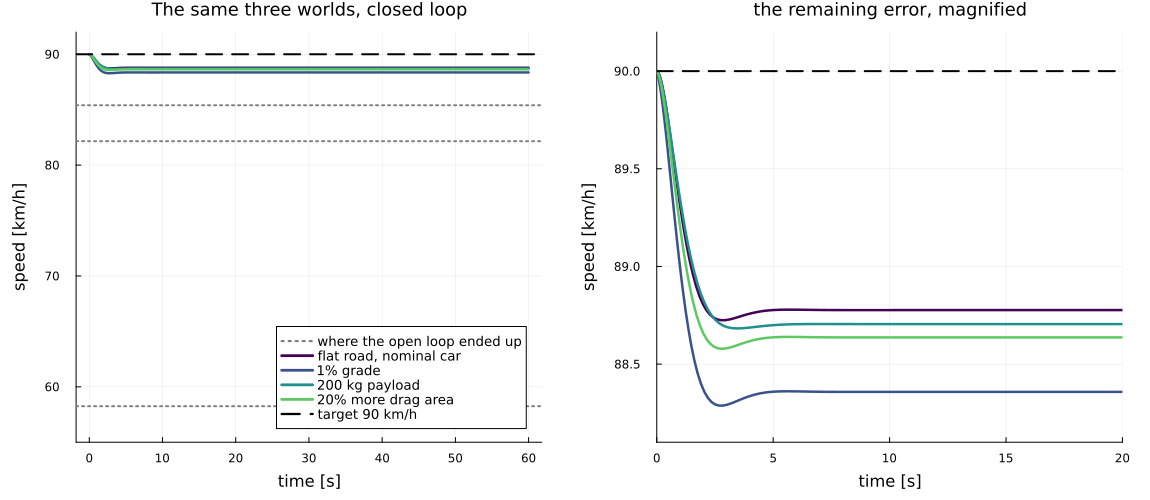

In [9]:
K = 25.0                        # N.m per km/h, well under the Ku = 114.58 of notebook 08
UNLIMITED = 1.0e6               # N.m — both torque ceilings, lifted out of the way

# 60 s, not the 400 s above, and the difference is the result. Same car, same disturbances.
CLOSED_STOP = 60.0

# `with_I` and `with_D` are structural parameters, so the integral and derivative paths are
# either compiled into the equations or absent entirely. `CruiseLoopStep` ships both off, and
# turning one on means rebuilding the model rather than setting a gain.
closed = [name => Scenarios.CruiseLoopTransient(
              k = K,
              v_lo = V_TARGET, v_hi = V_TARGET,
              grade = w.grade, m = w.m, CdA = w.CdA,
              T_max = UNLIMITED, y_max = UNLIMITED, stop = CLOSED_STOP)
          for (name, w) in WORLDS]

println("  world                     open loop    closed loop    error    holding torque")
for ((name, w), (_, sol)) in zip(WORLDS, closed)
    settled = signal(sol, "loop.plant.v_kmh")[2][end]
    println("  ", rpad(name, 24), "  ", lpad(round(predicted_speed(w), digits = 2), 6), " km/h",
            "  ", lpad(round(settled, digits = 2), 6), " km/h",
            "  ", lpad(round(V_TARGET - settled, digits = 2), 5), " km/h",
            "     ", lpad(round(signal(sol, "loop.controller.y")[2][end], digits = 2), 6), " N.m")
end

# On the open loop's own scale the four curves are indistinguishable, and on a scale that
# separates them the recovery is invisible. Both facts are the result, so both panels ship.
whole = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", ylims = (55, 92),
             title = "The same three worlds, closed loop", legend = :bottomright)
hline!(whole, [predicted_speed(w) for (_, w) in WORLDS[2:end]];
       ls = :dot, lw = 2, color = :grey, label = "where the open loop ended up")
for (n, (name, sol)) in enumerate(closed)
    t, y = signal(sol, "loop.plant.v_kmh")
    plot!(whole, t, y; lw = 2.5, label = name, color = palette(:viridis, 5)[n])
end
hline!(whole, [V_TARGET]; ls = :dash, lw = 2, color = :black, label = "target 90 km/h")

# The first twenty seconds, on the last two km/h: this loop is done inside five.
gap = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", legend = false,
           title = "the remaining error, magnified", xlims = (0, 20), ylims = (88.1, 90.2))
for (n, (_, sol)) in enumerate(closed)
    t, y = signal(sol, "loop.plant.v_kmh")
    plot!(gap, t, y; lw = 2.5, color = palette(:viridis, 5)[n])
end
hline!(gap, [V_TARGET]; ls = :dash, lw = 2, color = :black)

recovered = plot(whole, gap; layout = (1, 2), size = (1150, 500))
save_figure(recovered, "02-closed-loop-recovered")
recovered

One controller, three worlds it was never told about, one outcome. The dotted lines in the left
panel are where those same three worlds left the car in section 3; the open-loop runs spread
across 32 km/h, and these four sit inside half a km/h of each other. The controller has no model of
the car, no knowledge of the hill, the luggage or the wind, and it handles all three from a
single number: how far off it is.

Look at the last column. The torque each run settles at is different — the loop found the value
each world needed, without being told what that world was. That is the whole trick, and it is
worth saying plainly: **feedback converts a modeling problem into a measurement problem.**

Two things to notice before moving on.

**Look at the time axis.** The open-loop figure needed twenty minutes. The left panel here needed
one, and the right panel shows that every curve is settled to within 0.02 km/h in a little
over four seconds. Feedback has not merely operated this car, it has changed how fast the car responds —
and by a factor closer to sixty than to two. Hold that; section 6 is about it.

**There is still a gap,** and it is what the right-hand panel is for. None of the four curves
reaches 90 km/h. Each settles a little short, and by a different amount in each world — the
hill, which needs the most torque, settles furthest below. That gap is not a bug, it is not a tuning failure, and it will not go away if
you wait. It is notebook 03.


## 6. What feedback costs

The obvious costs are the boring ones: a sensor, a wire, and something to do the arithmetic.
They are real and they are not the interesting answer.

The interesting answer is in the two time axes.

> **Feedforward changes how a system is *operated*.**
> **Feedback changes what the system *is*.**

An open-loop command is an input to the car. The car's dynamics — its time constants, how
quickly a disturbance dies away, whether it dies away at all — are untouched by it, because the
command does not depend on what the car is doing. Feedforward cannot destabilize anything, and
the price of that safety is that it cannot stabilize anything either.

Feedback makes the input a function of the state. The controller sets the rate of change from
where the car currently is, and that is a new equation of motion. The car in section 5 is not
the car in section 3 being driven more attentively — it is a different dynamical system.

The arithmetic is short enough to do here. Let the speed sit 1 km/h below where it should be.
Open loop, the only thing that notices is drag, and drag pulls back with about 5.3 N. Closed
loop, the controller adds `k` times the gear ratio over the wheel radius — $25 \times 12.9$ —
which is another 323 N. The restoring force per km/h of error goes up by a factor of sixty, and
so the car's time constant comes down by one: about 74 s open loop at this speed, about 1.2 s
closed. Nobody asked for that. It fell out of closing the loop.

**Which cuts both ways, and this is the warning the rest of the lecture is built on.** If
closing a loop can take a sluggish car and make it quick, it can take a stable car and make it
oscillate. The same mechanism does both, and which one you get depends on numbers a diagram does
not show. Raise `k` here from 25 to 220 and this car never settles at all — notebook 03 runs
exactly that, and notebook 08 goes looking for the boundary on purpose.

A badly tuned loop is more dangerous than no loop at all, because no loop cannot make things
worse and a loop can. Which is why control engineering spends most of its effort on *analysis*
rather than on design: building a controller that works on a good day is not the hard part.
Showing that it cannot do harm on a bad one is the job.


## What this bought us

A working feedforward controller, and three entirely ordinary situations that defeat it while
the controller goes on being correct. The reason feedback exists: the world moves, and only an
error signal notices. And the warning that comes with it — feedback rewrites the dynamics, so it
can make things worse as easily as better.

What it did not buy us is a controller that arrives. Every closed-loop run in section 5 settled
short of 90 km/h, by a different amount in each world, and no amount of waiting closes that gap.

That is **notebook 03**, which starts from the least clever thing anyone could do with an error
signal — multiply it by a number — and finds out precisely where that stops working.
